In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io, zipfile
from urllib.request import urlopen
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score
from sklearn.cluster import KMeans
from scipy.stats import ttest_ind


In [18]:
DATA_URL = "https://archive.ics.uci.edu/static/public/352/online+retail.zip"
DATA_FILE = Path("Online Retail.xlsx")

if not DATA_FILE.exists():
    print("Downloading dataset...")
    response = urlopen(DATA_URL)
    zf = zipfile.ZipFile(io.BytesIO(response.read()))

    for file in zf.namelist():
        if file.endswith(".xlsx"):
            with open(DATA_FILE, "wb") as f:
                f.write(zf.read(file))

df = pd.read_excel(DATA_FILE)

In [19]:
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [21]:
df.columns = df.columns.str.strip()
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["CustomerID"] = df["CustomerID"].astype("Int64")

df["line_total"] = df["Quantity"] * df["UnitPrice"]

df = df.drop_duplicates()
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]
df = df.dropna(subset=["CustomerID"])

# Feature Engineering
df["month"] = df["InvoiceDate"].dt.month
df["hour"] = df["InvoiceDate"].dt.hour

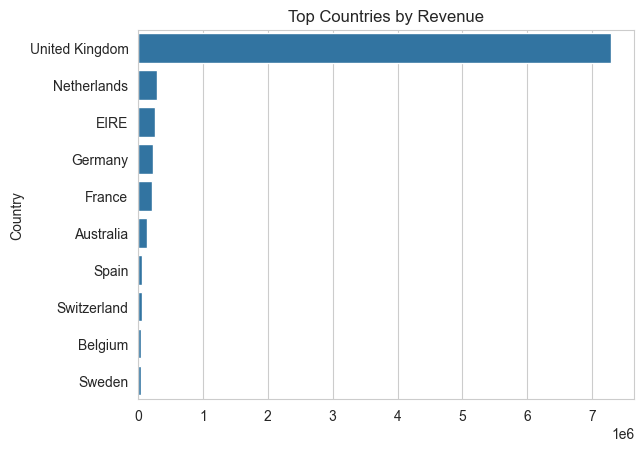

In [22]:
sns.set_style("whitegrid")
# 1. Top countries revenue
top = df.groupby("Country")["line_total"].sum().sort_values(ascending=False).head(10)
plt.figure()
sns.barplot(x=top.values, y=top.index)
plt.title("Top Countries by Revenue")
plt.show()

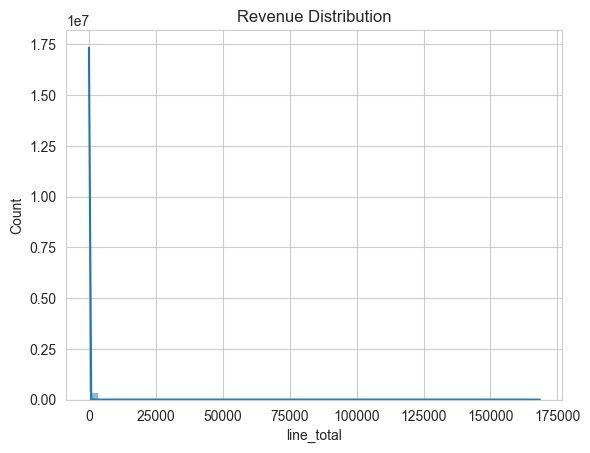

In [23]:
# 2. Revenue distribution
plt.figure()
sns.histplot(df["line_total"], bins=50, kde=True)
plt.title("Revenue Distribution")
plt.show()

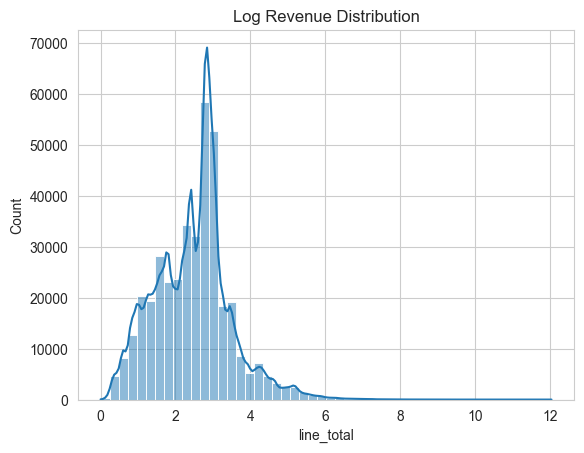

In [24]:
# 3. Log revenue distribution (better insight)
plt.figure()
sns.histplot(np.log1p(df["line_total"]), bins=50, kde=True)
plt.title("Log Revenue Distribution")
plt.show()


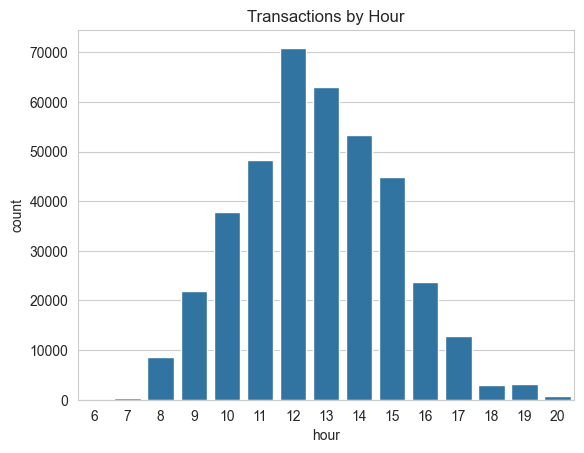

In [25]:
# 4. Sales by hour
plt.figure()
sns.countplot(x="hour", data=df)
plt.title("Transactions by Hour")
plt.show()


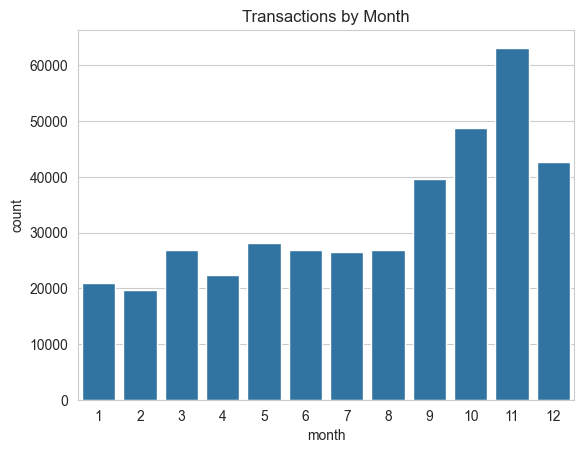

In [26]:
# 5. Sales by month
plt.figure()
sns.countplot(x="month", data=df)
plt.title("Transactions by Month")
plt.show()


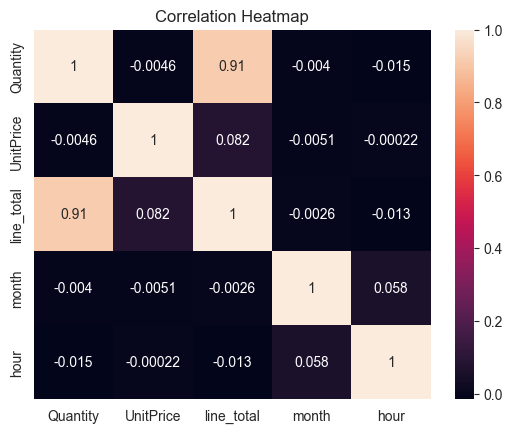

In [27]:
# 6. Correlation heatmap
plt.figure()
sns.heatmap(df[["Quantity", "UnitPrice", "line_total", "month", "hour"]].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()


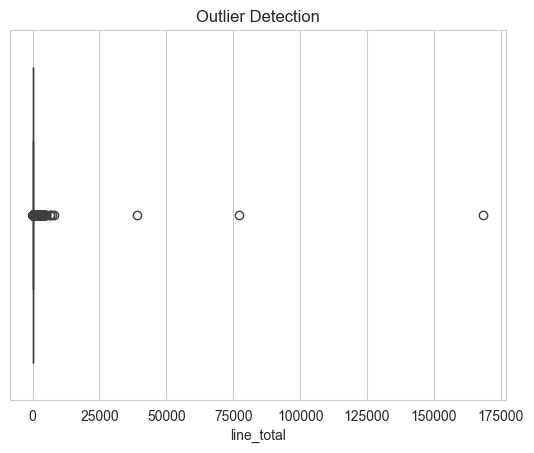

In [28]:
# 7. Boxplot for outliers
plt.figure()
sns.boxplot(x=df["line_total"])
plt.title("Outlier Detection")
plt.show()

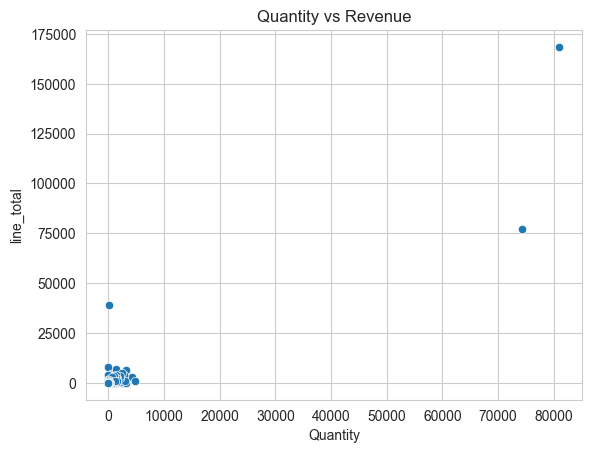

In [29]:
# 8. ScatterPlot
plt.figure()
sns.scatterplot(x="Quantity", y="line_total", data=df)
plt.title("Quantity vs Revenue")
plt.show()


In [46]:
invoice = df.groupby("InvoiceNo").agg({
    "line_total": "sum",
    "Quantity": "sum",
    "StockCode": "nunique",
    "UnitPrice": "mean",
    "CustomerID": "first",
    "Country": "first",
    "month": "first",
    "hour": "first"
}).reset_index()
invoice.columns = [
    "InvoiceNo", "total_amount", "total_quantity",
    "unique_products", "avg_price",
    "customer_id", "country", "month", "hour"
]


In [47]:
X = invoice[["total_quantity","unique_products","avg_price","month","hour","country"]]
y = invoice["total_amount"]
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), ["total_quantity","unique_products","avg_price","month","hour"]),
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["country"])
])
models = {
    "Linear": Pipeline([("prep",preprocessor),("model",LinearRegression())]),
    "Polynomial": Pipeline([("prep",preprocessor),("poly",PolynomialFeatures(2)),("model",LinearRegression())]),
    "Decision Tree": Pipeline([("prep",preprocessor),("model",DecisionTreeRegressor(max_depth=5))])
}
results = []
print("\nRegression Models:\n")
for name,model in models.items():
    model.fit(X_train,y_train)
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test,preds))
    r2 = r2_score(y_test,preds)
    results.append((name,rmse,r2))
    print(name,"RMSE:",rmse,"R2:",r2)
best = max(results,key=lambda x:x[2])
print("\nBest Regression Model:",best[0])


Regression Models:

Linear RMSE: 394.54021833898474 R2: 0.7296556188578944
Polynomial RMSE: 530.4939668909806 R2: 0.5112399677057178
Decision Tree RMSE: 391.46460996959195 R2: 0.7338540886648477

Best Regression Model: Decision Tree


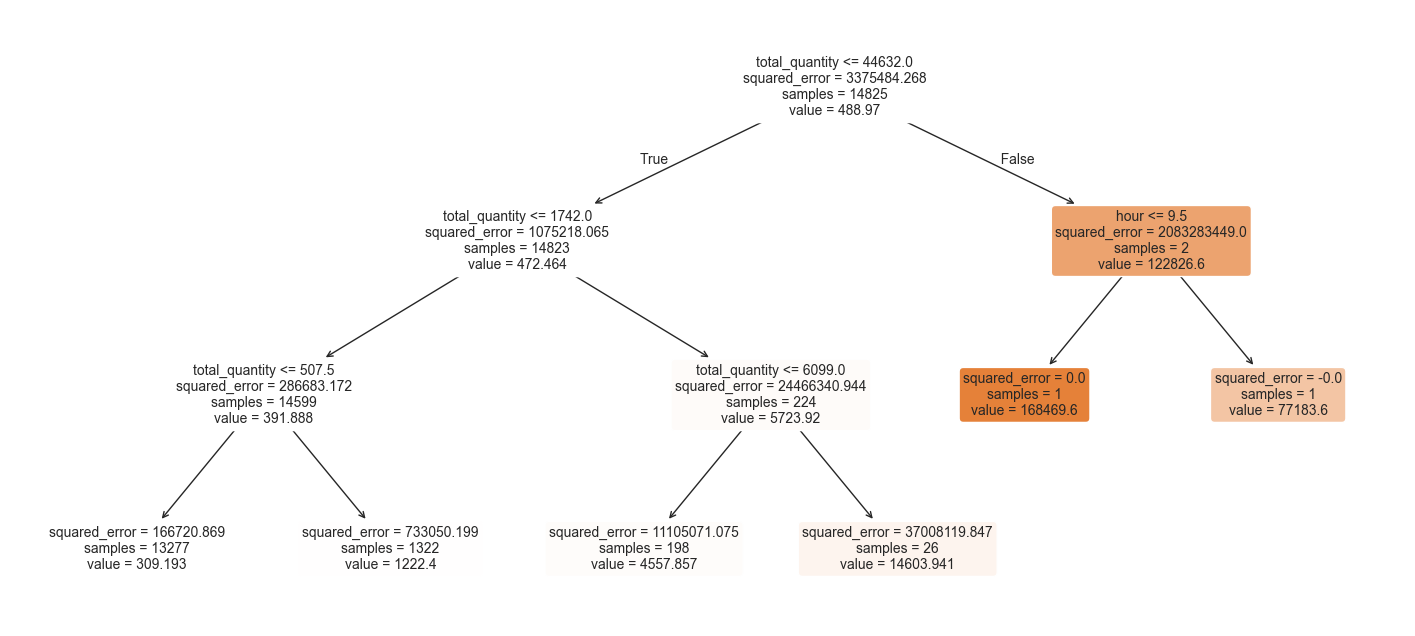

In [44]:
from sklearn.tree import plot_tree
num_features = ["total_quantity", "unique_products", "avg_price", "month", "hour"]
X_num = invoice[num_features]
y_num = invoice["total_amount"]
X_train, X_test, y_train, y_test = train_test_split(X_num, y_num, test_size=0.2, random_state=42)
tree_model = DecisionTreeRegressor(max_depth=3) 
tree_model.fit(X_train, y_train)
plt.figure(figsize=(18, 8))
plot_tree(
    tree_model,
    feature_names=num_features,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()

In [33]:
invoice["high_value"] = (invoice["total_amount"] > invoice["total_amount"].median()).astype(int)
Xc = X
yc = invoice["high_value"]
X_train,X_test,y_train,y_test = train_test_split(Xc,yc,test_size=0.2,random_state=42)
clf_models = {
    "Logistic": Pipeline([("prep",preprocessor),("model",LogisticRegression(max_iter=1000))]),
    "Decision Tree": Pipeline([("prep",preprocessor),("model",DecisionTreeClassifier(max_depth=5))])
}
print("\nClassification Models:\n")
for name,model in clf_models.items():
    model.fit(X_train,y_train)
    preds = model.predict(X_test)
    print(name,"Accuracy:",accuracy_score(y_test,preds))



Classification Models:

Logistic Accuracy: 0.8192608578365255
Decision Tree Accuracy: 0.868626922039385


In [41]:
from scipy.stats import ttest_ind
weekday = df[df["InvoiceDate"].dt.dayofweek < 5]["line_total"]
weekend = df[df["InvoiceDate"].dt.dayofweek >= 5]["line_total"]
t_stat, p_val = ttest_ind(weekday, weekend, equal_var=False)
print("\nHypothesis Test for Weekday and Weekend Sales")
print("p-value:", p_val)
alpha = 0.05

if p_val < alpha:
    print("Result: Reject Null Hypothesis")
    print("Conclusion: There is a significant difference between weekday and weekend sales.")
else:
    print("Result: Fail to Reject Null Hypothesis")
    print("Conclusion: No significant difference between weekday and weekend sales.")
print("\nMean Weekday Sales:", weekday.mean())
print("Mean Weekend Sales:", weekend.mean())


Hypothesis Test for Weekday and Weekend Sales
p-value: 1.6238525423964228e-83
Result: Reject Null Hypothesis
Conclusion: There is a significant difference between weekday and weekend sales.

Mean Weekday Sales: 24.441047945577406
Mean Weekend Sales: 12.832293030778281


In [42]:
print("\nStatistical Summary")
print("Mean:",invoice["total_amount"].mean())
print("Median:",invoice["total_amount"].median())
print("Std Dev:",invoice["total_amount"].std())


Statistical Summary
Mean: 479.56016047917126
Median: 302.575
Std Dev: 1678.0825798864128
